In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import pandas as pd
import torch
import matplotlib.pyplot as plt



In [ ]:
#load in the train data - explore and clean


#path to train images
path = r"C:\Users\Abasj\OneDrive\Documents\Diabetic Retinopathy\Dataset\raw\train_images"
#path to csv file containing img id code and grading
label_csv = r"C:\Users\Abasj\OneDrive\Documents\Diabetic Retinopathy\Dataset\raw\train.csv"


if not os.path.isfile(label_csv):
    print(f"File not found: {label_csv}")
else:
    pass
    

try:
    with open (label_csv, "r") as f:
     #our csv file
     df = pd.read_csv(label_csv)
except Exception as e:
   raise FileNotFoundError("this file does not exist", e)   

  

id_code, diagnosis= df["id_code"][0], df["diagnosis"][0]

print("id_code:", id_code , ": diagnosis:" ,diagnosis)

print("------------------------------------------------")

#print the first 5 labels
print(df.head())
#print the last 5 labels
print(df.tail())




id_code: 000c1434d8d7 : diagnosis: 2
------------------------------------------------
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
           id_code  diagnosis
3657  ffa47f6a7bf4          2
3658  ffc04fed30e6          0
3659  ffcf7b45f213          2
3660  ffd97f8cd5aa          0
3661  ffec9a18a3ce          2


In [ ]:
#load in the train data - explore and clean
training_images=[]
missing_labels=[]
#count the sample distribution per class 
count={"No DR" :0 , "Mild DR": 0, "Moderate DR": 0, "Severe DR": 0, "Proliferative DR" : 0}
IMG_SIZE = 224



#iterate through the data in subsets, iterating through x images at a time
#for chunk in np.array_split(df, 1000):
for idx ,i in tqdm(df.iterrows(), total=len(df)):
    try:
        img_path = os.path.join(path, f"{i['id_code']}.png")
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        #normalize pixel values
        img = img / 255.0
        label = i["diagnosis"]

        #ensure there are no corrupted files
        if img is None:
            print(f"could not read image at path {img_path}")
            #skip the current iteration
            continue
            
        
        if pd.isna(label):
            #if any image within the csv file does not contain a label, we append the image to the missing_labels, in which we can later filter out
            missing_labels.append(np.array(img))

        #count the distribution of samples per class
        if label == 0:
            count["No DR"]+=1

        elif label == 1:
            count["Mild DR"]+=1

        elif label == 2:
            count["Moderate DR"]+=1

        elif label == 3:
            count["Severe DR"]+=1

        elif label == 4:
            count["Proliferative DR"]                   

        #convert each image into a one hot encoding
        #np.eye() allows you define the number of output classes and the [] after it defines which class will be hot
        #np.eye(2)[0] for instance meaning [1,0], we have 2 classes and the 0th index is hot meaning that is our true label
        training_images.append([np.array(img),np.eye(5)[i["diagnosis"]]])    

    except Exception as e:
        print(f"There was an error processing  Image : {img_path}")

print(training_images[0][0].shape)
print(training_images[0])        


    

100%|██████████| 3662/3662 [05:05<00:00, 12.00it/s]


(224, 224, 3)
[array([[[2, 1, 3],
        [2, 1, 3],
        [2, 2, 2],
        ...,
        [1, 1, 1],
        [1, 0, 2],
        [2, 1, 3]],

       [[2, 1, 3],
        [2, 1, 3],
        [1, 1, 1],
        ...,
        [2, 2, 2],
        [1, 0, 2],
        [1, 0, 2]],

       [[2, 2, 2],
        [2, 2, 2],
        [1, 0, 2],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [2, 2, 2]],

       ...,

       [[1, 1, 1],
        [1, 1, 1],
        [2, 2, 2],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [1, 1, 1]],

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 0, 2],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [3, 3, 3],
        [1, 1, 1],
        [2, 2, 2]]], shape=(224, 224, 3), dtype=uint8), array([0., 0., 1., 0., 0.])]
The number of msising labels found in the dataset are : 0


In [ ]:
#check to see if there are any images with missing labels
print(f"The number of msising labels found in the dataset are : {len(missing_labels)}")

Min pixel value: 0, Max pixel value: 255
3662
(224, 224, 3)


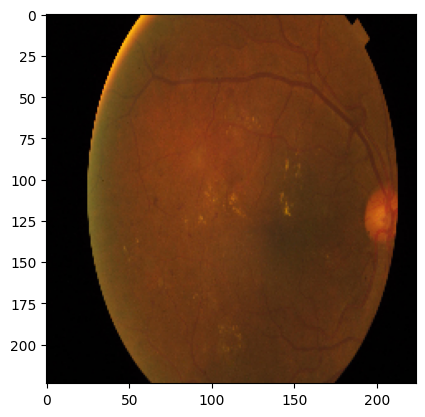

In [7]:
#print max and min pixel values of our image to see if normalized already or not
print(f"Min pixel value: {training_images[0][0].min()}, Max pixel value: {training_images[0][0].max()}")

#printing the length of our dataset
print(len(training_images))
print(training_images[0][0].shape)
#(2136, 3216, 3), this represents the shape of each image with 3 channels RGB

#visualize the first fundus image in the datset, ensure its in RGB
plt.imshow(cv2.cvtColor(training_images[0][0], cv2.COLOR_BGR2RGB))
plt.show()